In [9]:
import pandas as pd
import numpy as np
import time

df = pd.read_csv('cfpb_cleaned.csv', parse_dates=['Date received', 'Date sent to company'])
print(df.shape)
df.head(2)

(49850, 19)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,days_to_route,narrative_word_count,got_relief
0,2025-12-29 11:33:13+00:00,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,A collection account is being reported on my c...,No public response,ALLY FINANCIAL INC.,OK,741XX,NaN,Web,2026-01-07 15:43:44+00:00,Closed with explanation,Yes,18337910,9,113,0
1,2025-12-29 14:17:25+00:00,Checking or savings account,Checking account,Opening an account,Account opened without my consent or knowledge,Someone opened a XXXX account connecting it to...,Company has responded to the consumer and the ...,"ARVEST BANK GROUP, INC.",AR,72023,Older American,Web,2025-12-29 14:36:38+00:00,Closed with explanation,Yes,18339989,0,106,0


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [11]:
## Sentiment scores
def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

start = time.time()
df['sentiment'] = df['Consumer complaint narrative'].apply(get_sentiment)
print(f"Done in {time.time()-start:.1f}s")

print(df['sentiment'].describe())

Done in 40.2s
count    49850.000000
mean        -0.177284
std          0.719042
min         -1.000000
25%         -0.886000
50%         -0.361200
75%          0.571900
max          0.999800
Name: sentiment, dtype: float64


In [12]:
print(df.groupby('Product')['sentiment'].mean())

# Eyeball a couple of extreme examples to confirm sentiment makes sense
print("\nMost negative example:")
print(df.loc[df['sentiment'].idxmin(), 'Consumer complaint narrative'][:300])

print("\nMost positive example:")
print(df.loc[df['sentiment'].idxmax(), 'Consumer complaint narrative'][:300])

Product
Checking or savings account   -0.384299
Credit card                   -0.093484
Debt collection               -0.114499
Name: sentiment, dtype: float64

Most negative example:
I am filing this complaint against Oliphant USA LLC and Accelerated Inventory Management

for systematic violations of the Fair Debt Collection Practices Act ( FDCPA ) 15 U.S.C. 1692 et seq. and Fair Credit Reporting Act ( FCRA ) 15 U.S.C. 1681 et seq.

These violations include : Collection agency r

Most positive example:
I have attempted to resolve this with the support representatives, whom stated multiple times someone would call me but over two days no one ever called me. it was always myself calling them. they continued misinforming me about the case. Here is a letter I typed out and the chat transcripts. but th


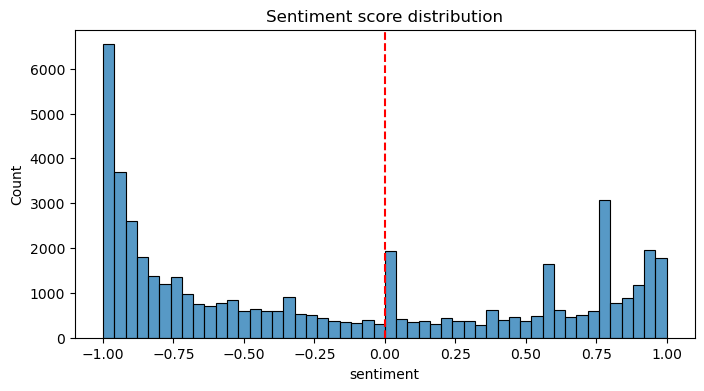

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['sentiment'], bins=50)
plt.title('Sentiment score distribution')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Quick timing test on a small batch before committing to the full run
sample_texts = df['Consumer complaint narrative'].head(200).tolist()
start = time.time()
sample_embeddings = model.encode(sample_texts, show_progress_bar=True, batch_size=32)
elapsed = time.time() - start
print(f"{elapsed:.1f}s for 200 docs -> estimated {elapsed/200*len(df)/60:.1f} min for full dataset")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

1.2s for 200 docs -> estimated 5.0 min for full dataset


In [9]:
texts = df['Consumer complaint narrative'].tolist()

start = time.time()
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
)
print(f"Done in {(time.time()-start)/60:.1f} min")
print(embeddings.shape)

# Save to disk immediately - this is the expensive step, never recompute it
np.save('narrative_embeddings.npy', embeddings)

Batches:   0%|          | 0/1558 [00:00<?, ?it/s]

Done in 3.7 min
(49850, 384)


In [15]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [16]:
import re

def clean_for_topics(text):
    text = re.sub(r'X{2,}', ' ', text)  # remove XXXX redaction placeholders
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['narrative_for_topics'] = df['Consumer complaint narrative'].apply(clean_for_topics)
print(df['narrative_for_topics'].iloc[0][:300])

A collection account is being reported on my credit file that has not been properly validated. I exercised my rights under the Fair Debt Collection Practices Act ( FDCPA ) by requesting validation of the alleged debt. The furnisher failed to provide any legitimate documentation proving that the debt


In [17]:
from umap import UMAP
from hdbscan import HDBSCAN

# Explicit, lighter-weight UMAP - low_memory=True trades speed for RAM safety
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    low_memory=True,
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=False  # saves memory, we don't need soft predictions
)

vectorizer_model = CountVectorizer(stop_words='english', min_df=10, ngram_range=(1,2))

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True
)

In [18]:
embeddings = np.load('narrative_embeddings.npy').astype(np.float32)  # float32 halves memory vs float64

start = time.time()
topics, _ = topic_model.fit_transform(df['narrative_for_topics'].tolist(), embeddings)
print(f"Done in {(time.time()-start)/60:.1f} min")

df['topic'] = topics
print("Number of topics found:", len(set(topics)) - (1 if -1 in topics else 0))
print(topic_model.get_topic_info().head(20))

2026-06-30 10:50:01,506 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-06-30 10:50:39,983 - BERTopic - Dimensionality - Completed ✓
2026-06-30 10:50:39,984 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 10:50:42,766 - BERTopic - Cluster - Completed ✓
2026-06-30 10:50:42,772 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 10:50:46,717 - BERTopic - Representation - Completed ✓


Done in 0.8 min
Number of topics found: 59
    Topic  Count                                               Name  \
0      -1  19850                   -1_debt_credit_account_reporting   
1       0   1871                       0_chase_chase bank_card_bank   
2       1   1608                  1_wells_fargo_wells fargo_account   
3       2   1503         2_identity_identity theft_theft_fraudulent   
4       3   1452             3_debt_collection_validation_reporting   
5       4   1445        4_reporting_information_inaccurate_reported   
6       5   1367                        5_capital_card_ones_account   
7       6   1224                            6_check_funds_bank_hold   
8       7   1089                       7_citibank_citi_card_dispute   
9       8    996           8_bank_transactions_bank america_america   
10      9    964          9_chime_unauthorized_transactions_dispute   
11     10    949                      10_calls_calling_phone_called   
12     11    904  11_accurate_1681

In [21]:
def strip_companies_v2(text):
    words = text.split()
    keep = []
    for w in words:
        w_clean = w.lower().strip('.,()')
        # check if word STARTS WITH any company token (catches chases, citibanks, etc.)
        if not any(w_clean.startswith(cw) and len(cw) > 3 for cw in company_words):
            keep.append(w)
    return ' '.join(keep)

df['narrative_for_topics_v3'] = df['narrative_for_topics'].apply(strip_companies_v2)
print(df['narrative_for_topics_v3'].iloc[0][:300])

A collection account is being reported on my file that has not been properly validated. I exercised my rights under the Collection Practices Act ( FDCPA ) by requesting validation of the alleged The furnisher failed to provide any legitimate documentation proving that the is mine, that the amount is


In [ ]:
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', low_memory=True, random_state=42)

hdbscan_model = HDBSCAN(
    min_cluster_size=300,     # much higher -> consolidates into fewer, broader themes
    min_samples=5,            # lower -> fewer points get flagged as outliers
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=False
)

vectorizer_model = CountVectorizer(stop_words='english', min_df=10, ngram_range=(1,2))

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True
)

start = time.time()
topics, _ = topic_model.fit_transform(df['narrative_for_topics_v3'].tolist(), embeddings)
print(f"Done in {(time.time()-start)/60:.1f} min")

df['topic'] = topics
n_outliers = (df['topic'] == -1).sum()
print(f"Topics found: {len(set(topics)) - (1 if -1 in topics else 0)}, Outliers: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print(topic_model.get_topic_info().head(25))

2026-06-30 10:53:47,571 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 10:54:21,598 - BERTopic - Dimensionality - Completed ✓
2026-06-30 10:54:21,599 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 10:54:22,271 - BERTopic - Cluster - Completed ✓
2026-06-30 10:54:22,275 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 10:54:25,907 - BERTopic - Representation - Completed ✓


Done in 0.6 min
Topics found: 28, Outliers: 15570 (31.2%)
    Topic  Count                                               Name  \
0      -1  15570                  -1_account_reporting_card_falsely   
1       0  14570          0_collection_reporting_account_validation   
2       1   1884                         1_account_card_funds_check   
3       2   1600                         2_account_fraud_claim_card   
4       3   1507                         3_check_funds_account_hold   
5       4   1364                        4_card_account_ones_dispute   
6       5   1203             5_transactions_fraud_card_unauthorized   
7       6   1109                        6_citi_card_account_dispute   
8       7    966        7_transactions_unauthorized_dispute_account   
9       8    865                           8_accurate_15 usc_usc_15   
10      9    711                 9_funding_llc_reporting_validation   
11     10    659                    10_merchant_refund_dispute_item   
12     11    644   

Exception ignored in: <function ResourceTracker.__del__ at 0x110f0a0c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107d0e0c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104e160c0>
Traceback (most recent call last

In [23]:
df['topic'] = topics
topic_info = topic_model.get_topic_info()
print(topic_info[['Topic','Count','Name']].to_string())

    Topic  Count                                                    Name
0      -1  15570                       -1_account_reporting_card_falsely
1       0  14570               0_collection_reporting_account_validation
2       1   1884                              1_account_card_funds_check
3       2   1600                              2_account_fraud_claim_card
4       3   1507                              3_check_funds_account_hold
5       4   1364                             4_card_account_ones_dispute
6       5   1203                  5_transactions_fraud_card_unauthorized
7       6   1109                             6_citi_card_account_dispute
8       7    966             7_transactions_unauthorized_dispute_account
9       8    865                                8_accurate_15 usc_usc_15
10      9    711                      9_funding_llc_reporting_validation
11     10    659                         10_merchant_refund_dispute_item
12     11    644                     11_reporting_a

In [24]:
df.to_csv('cfpb_with_nlp_features.csv', index=False)
np.save('narrative_embeddings.npy', embeddings)  # already saved, just confirming it's current
print("Saved:", df.shape)

Saved: (49850, 24)
